In [1]:
import pandas as pd

df = pd.read_csv("train.csv")

df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [2]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)'],
      dtype='object')

In [3]:
df.shape

(45593, 20)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

In [5]:
df.isnull().sum()

,0
ID,0
Delivery_person_ID,0
Delivery_person_Age,0
Delivery_person_Ratings,0
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,0


In [7]:
x = df.drop('Time_taken(min)', axis=1)

y = df['Time_taken(min)']

In [8]:
df = df.drop([
    'ID',
    'Delivery_person_ID',
    'Order_Date',
    'Time_Orderd',
    'Time_Order_picked'
], axis=1)

In [9]:
df.head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,37,4.9,22.745049,75.892471,22.765049,75.912471,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,34,4.5,12.913041,77.683237,13.043041,77.813237,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,23,4.4,12.914264,77.678400,12.924264,77.688400,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,38,4.7,11.003669,76.976494,11.053669,77.026494,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,32,4.6,12.972793,80.249982,13.012793,80.289982,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])

In [11]:
x = df.drop('Time_taken(min)', axis=1)

y = df['Time_taken(min)']

In [12]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)

In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(x_train, y_train)

LinearRegression()

In [14]:
prediction = model.predict(x_test)

print(prediction)

[27.46438649 20.03412294 23.48835814 ... 11.57098632 15.74248915
  9.25630928]


In [15]:

from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, prediction)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 5.813985074452074


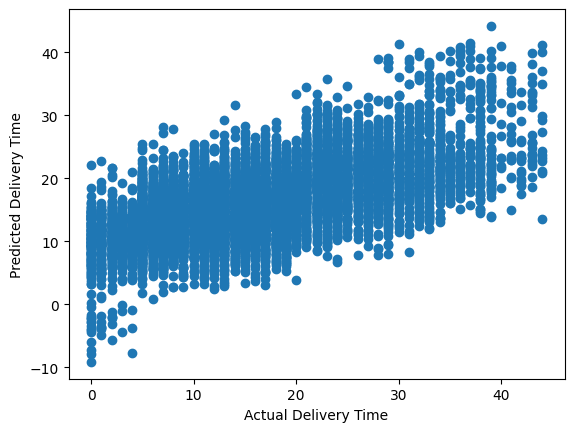

In [16]:
import matplotlib.pyplot as plt

plt.scatter(y_test, prediction)

plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")

plt.show()

In [19]:
print(x.columns)

print(len(x.columns))

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Weatherconditions',
       'Road_traffic_density', 'Vehicle_condition', 'Type_of_order',
       'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City'],
      dtype='object')
14


In [20]:
custom_prediction = model.predict([[25, 4.5, 12.5, 77.5, 12.6, 77.6,
                                    2, 1, 3, 2, 1, 0, 1, 2]])

print(custom_prediction)

[32.15484827]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [21]:
from sklearn.metrics import r2_score

score = r2_score(y_test, prediction)

print("R2 Score:", score)

R2 Score: 0.40009470137696046


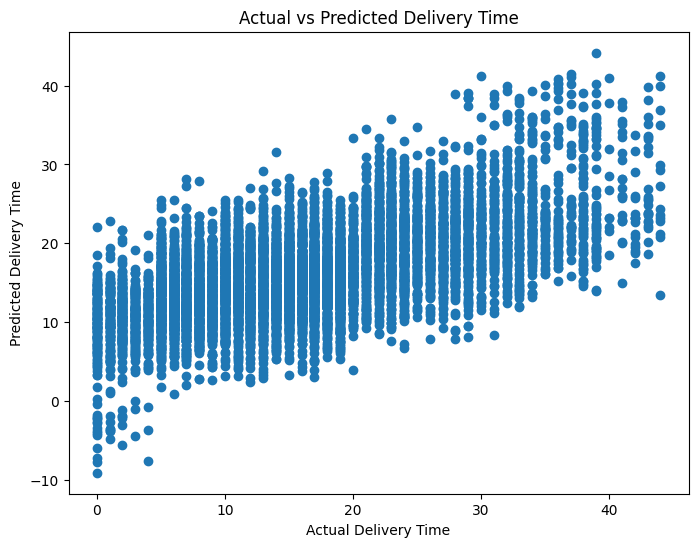

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, prediction)

plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")

plt.title("Actual vs Predicted Delivery Time")

plt.show()

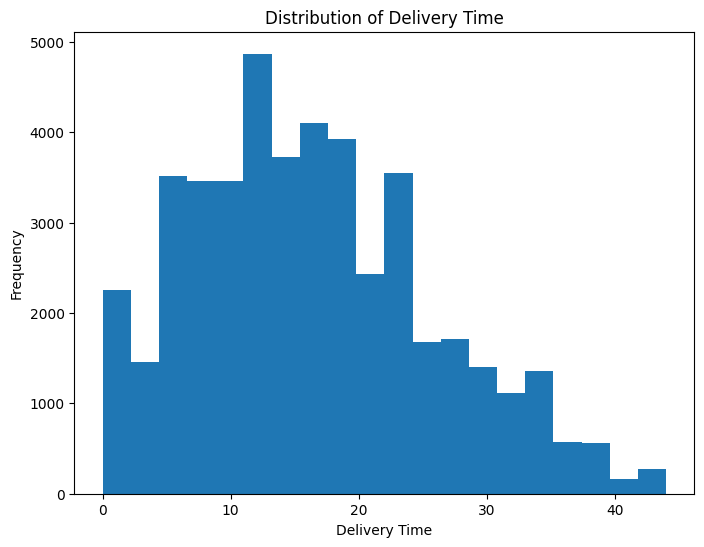

In [23]:
plt.figure(figsize=(8,6))

plt.hist(y, bins=20)

plt.xlabel("Delivery Time")
plt.ylabel("Frequency")

plt.title("Distribution of Delivery Time")

plt.show()

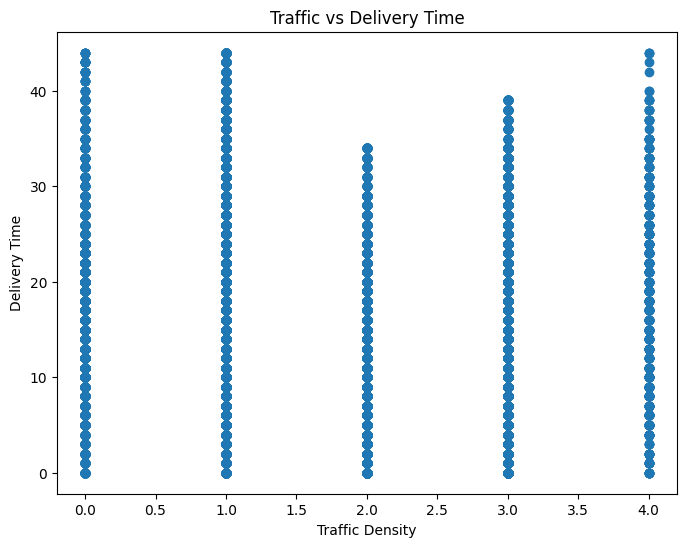

In [24]:
plt.figure(figsize=(8,6))

plt.scatter(df['Road_traffic_density'], df['Time_taken(min)'])

plt.xlabel("Traffic Density")
plt.ylabel("Delivery Time")

plt.title("Traffic vs Delivery Time")

plt.show()

# Conclusion

The Linear Regression model successfully predicts food delivery time
using factors like traffic density, weather conditions,
vehicle condition, and delivery location.

The project demonstrates data preprocessing,
feature engineering, model training,
and prediction using Machine Learning.
